In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from jax import random
import seaborn as snb

# distributions
from scipy.stats import norm
from scipy.stats import multivariate_normal as mvn
from scipy.stats import poisson

# for plotting and visualization
from exercise8 import plot_predictions
from exercise8 import eval_density_grid

# style stuff
snb.set_style('darkgrid')
snb.set(font_scale=1.25)

# 02477 Bayesian Machine Learning - Exercise 8

______________________

The purpose of this exercise is to become familiar with sampling-based methods. We will briefly touch **ancestral sampling** and **importance sampling**, but spend most of the time diving into **Markov Chain Monte Carlo methods** via the **Metropolis-Hastings algorithm**. After studying the properties of the algorithms, we will apply to a Poisson regression model for fully Bayesian inference.

**Content**

- Part 1: Ancestral sampling
- Part 2: Implementing the Metropolis-Hastings algorithm
- Part 3: The Metropolis-Hastings algorithm for 1D and 2D problems 
- Part 4: Metroplis-Hastings for Bayesian Poisson regression
- Part 5: Importance sampling

__________________

For later convenience, we will implement the density of the normal and the so-called half-normal distributions:

In [2]:
# Normal distribution
log_npdf = lambda x, m, v: -0.5*(x-m)**2/(v) - 0.5*jnp.log(2*jnp.pi*v)
npdf = lambda x, m, v: jnp.exp(log_npdf(x, m, v))

# Half-normal distribution
log_half_npdf = lambda x, m, v: jnp.log(2) -0.5*(x-m)**2/(v) - 0.5*jnp.log(2*jnp.pi*v)
half_npdf = lambda x, m, v: jnp.exp(log_half_npdf(x, m, v))

## Part 1:  Ancestral sampling

**Ancestral Sampling from a Directed Probabilistic Model**

Ancestral sampling is a simple and powerful technique for generating samples from a joint probability distribution defined by a sequence of conditional dependencies. The key idea is to sample in topological order of the variables, starting from the root nodes (those with no parents), and then progressing to variables that depend on them.

Consider the following generative model over four random variables $x_1, x_2, x_3, x_4$:

$$
\begin{aligned}
x_1 &\sim \mathcal{N}(0, 3) &\text{(root node)} \\
x_2 &\sim \mathcal{N}(1, 1) &\text{(another root node)} \\
x_3 \mid x_1, x_2 &\sim \mathcal{N}(x_1 + x_2, 2) &\text{(depends on } x_1 \text{ and } x_2) \\
x_4 \mid x_3 &\sim \mathcal{N}(x_3^2, 1) &\text{(depends nonlinearly on } x_3)
\end{aligned}
$$

The corresponding joint distribution factorizes according to the graph structure:

$$
p(x_1, x_2, x_3, x_4) = p(x_1)\cdot p(x_2)\cdot p(x_3 \mid x_1, x_2) \cdot p(x_4 \mid x_3)
$$

This structure corresponds to a Bayesian network, where each variable is conditionally independent of non-descendants given its parents.

---

**Intuition Behind Each Step**

- $x_1$ and $x_2$ are sampled independently from their priors since they have no parents. They form the roots of the graph.

- $x_3$ is a child node that depends on both $x_1$ and $x_2$—it’s centered at their sum, i.e., $x_3 \sim \mathcal{N}(x_1 + x_2, 2)$. This introduces a linear relationship between the earlier variables and $x_3$.

- $x_4$ depends nonlinearly on $x_3$—its mean is the square of $x_3$. Thus, this model can capture complex (nonlinear) structure in the data.

---

**Ancestral Sampling Procedure**

To generate a single sample from the joint distribution, follow these steps in ancestral order:

1. Sample $x_1 \sim \mathcal{N}(0, 3)$

2. Sample $x_2 \sim \mathcal{N}(1, 1)$

3. Given $x_1, x_2$, sample $x_3 \sim \mathcal{N}(x_1 + x_2, 2)$

4. Given $x_3$, sample $x_4 \sim \mathcal{N}(x_3^2, 1)$
****
Each sample is drawn using previously sampled values from its parents, following the dependency structure.
****


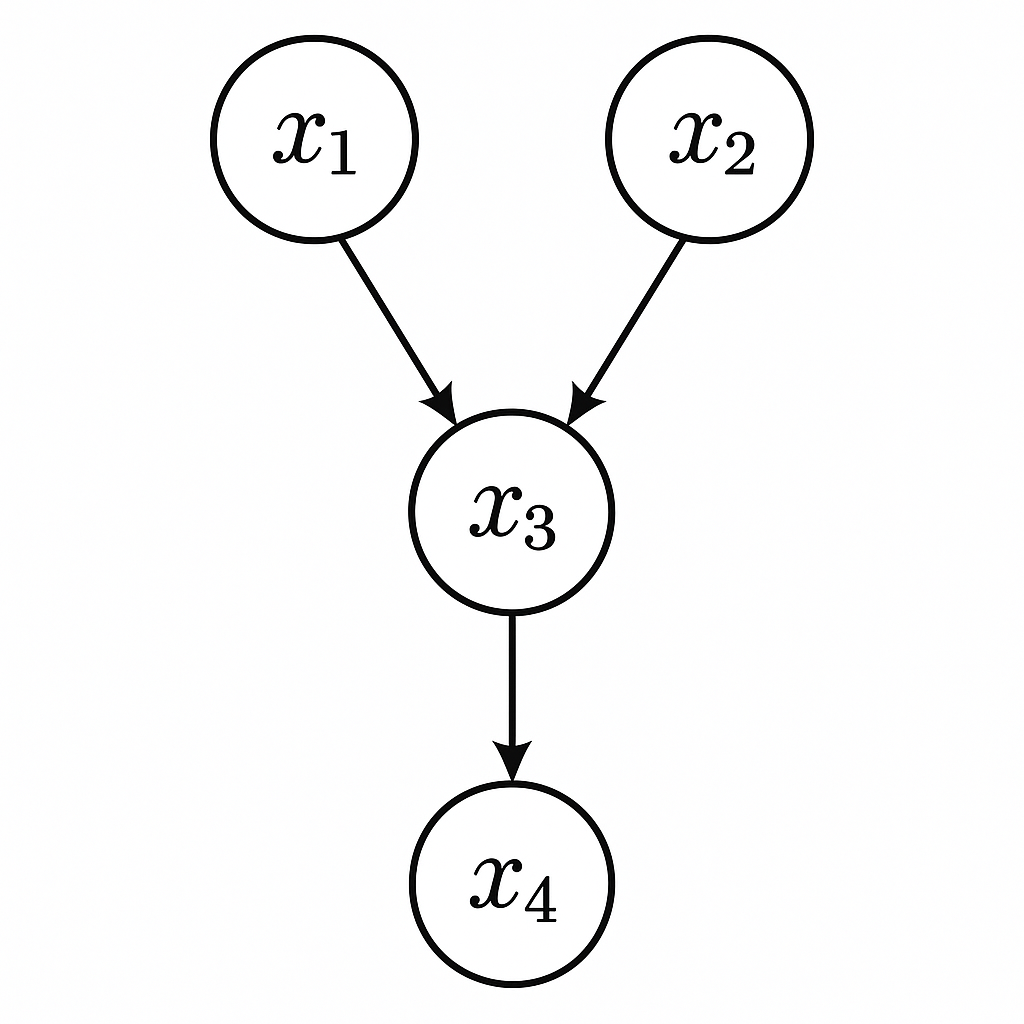

**Task 1.1**: Use ancestral sampling to generate $S = 1000$ samples from the joint distribution $p(x_1, x_2, x_3, x_4)$.

*Hints*:
-  *Start by generating samples from the marginal distributions of $p(x_1)$ and $p(x_2)$, i.e. $x_1^{(i)} \sim p(x_1)$ and $x_2^{(i)} \sim p(x_2)$ for $i = 1, \dots, S$*
-  *Next, then for each pair of samples $x_1^{(i)}, x_2^{(i)}$ generate a sample from $x_3^{(i)} \sim p(x_3|x_1^{(i)}, x_2^{(i)})$ and so on.*
-  *You can use `jax.random.normal(key, shape=(S,))` to generate an array of `S` i.i.d. samples from $\mathcal{N}(0, 1)$*
-  *Recall: The `key`-argument in JaX determines the state for the random number generator, so if you call `jax.random.normal(key, shape=(S,))` several times in your code with the same key, then you'll get the exact same numbers every time. So make you to provide a different `key`.
- *You can split a single key into multiple keys as follows: `key1, key2, key3, key4 = random.split(key, num=4)`.*
-  More information about random number generation in JaX can be found here: https://docs.jax.dev/en/latest/random-numbers.html*

_____

#### 🧠 Drawing from a Normal Distribution

To draw samples from a normal distribution:

$$
x \sim \mathcal{N}(\mu, \sigma^2)
$$

we use the **reparameterization trick**:

$$
x = \mu + \sigma \cdot z
$$

where:
- $z \sim \mathcal{N}(0, 1)$ is a **standard normal variable**
- $\sigma = \sqrt{\text{variance}}$

This works because most libraries (like JAX or NumPy) generate standard normal noise, which we transform to match any desired $\mu$ and $\sigma^2$.

---

### 🐍 Python/JAX Implementation

```python
import jax.numpy as jnp
from jax import random  

# Step 1: Initialize the random key (JAX uses functional RNG)
key = random.PRNGKey(0)

# Step 2: Set parameters
S = 1000                 # Number of samples
mu = 0                   # Mean
var = 9                  # Variance
sigma = jnp.sqrt(var)    # Standard deviation = sqrt(variance)

# Step 3: Sample from the target distribution
x = mu + sigma * random.normal(key, shape=(S,))
```
💬 Notes
- Why ```jnp.sqrt(var)```?
    - Because the formula uses the standard deviation, not variance.

- Why use ```random.normal```?
    - It returns samples from $\mathcal{N}(0, 1)$, which we scale to match $\mu$ and $\sigma^2$.

- Why ```shape=(S,)```?
    - This gives you $S$ samples in a 1D array.

- Why ```PRNGKey```?
    - JAX uses pure functional random number generation, so you must manage the key manually.
________________________


```python
import matplotlib.pyplot as plt

plt.hist(x, bins=50, density=True, alpha=0.6, color="skyblue")
plt.title("Histogram of Samples from 𝒩(μ=0, σ²=9)")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True)
plt.show()
```

In [3]:
# create a pseudorandom number generator key, derived from a seed (it is a fixed 2-element jnp.array)
key = random.PRNGKey(0)
# 
print(f"The random generated key: {key}")


# Number of samples 
S = 1000
print(f"Number of samples {S}")
print("")


N = 5 # specify how many keys you want 

k1, k2, k3, k4, k5 = random.split(key, N)
print("Generating a random numbers: ")
print(random.normal(k1))      # One number
print(random.normal(k2))      # Different number


The random generated key: [0 0]
Number of samples 1000

Generating a random numbers: 
1.0040143
-2.4424558


$x_1 \sim \mathcal{N}(0, 3) \text{ (root node)}$

In [4]:
mu1 = 0
sigma1 = 3
x1 = mu1 + jnp.sqrt(sigma1)* random.normal(k1, shape=(S, )) 

$x_2 \sim \mathcal{N}(1, 1) \text{ (another root node)}$

In [5]:
mu2 = 1 
sigma2 = 1 
x2 = mu2 + jnp.sqrt(sigma2) * random.normal(k2, shape=(S, ))

$x_3 \sim \mathcal{N}(x_1 + x_2, 2) \text{ (depends on } x_1 \text{ and } x_2)$

In [6]:
mu_3 = x1 + x2 
sigma3 = 2 
x3 = mu_3 + jnp.sqrt(sigma3) * random.normal(k3, shape=(S, ))

$x_4 \sim \mathcal{N}(x_3^2, 1) \text{ (depends nonlinearly on } x_3)$

In [7]:
mu_4 = x3**2
sigma4 = 1 
x4 = mu_4 + jnp.sqrt(sigma4) * random.normal(k4, shape=(S, )) 

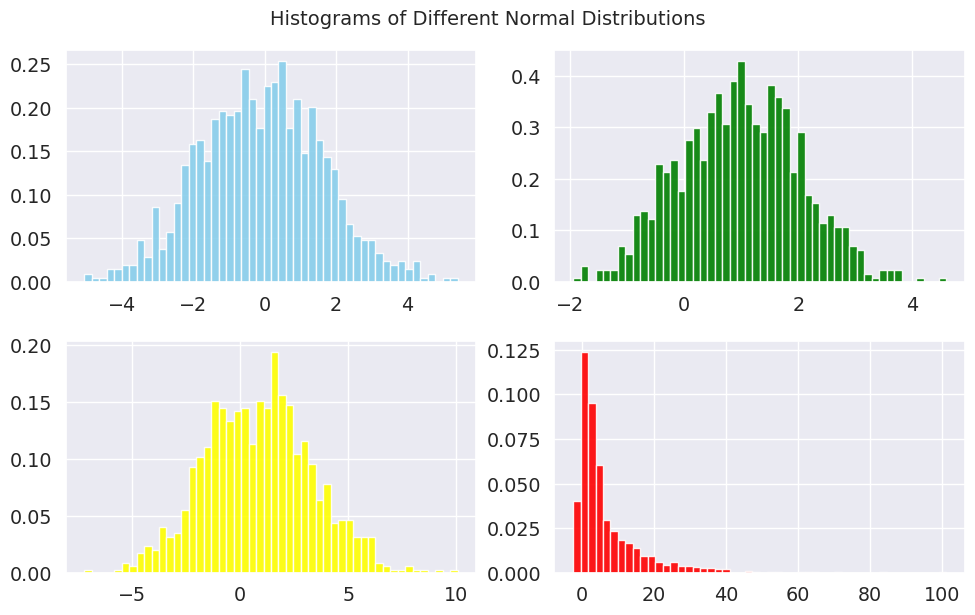

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()  # Turn 2x2 grid into flat list of axes

axes[0].hist(x1, bins=50, density=True, alpha=0.9, color='skyblue')
axes[1].hist(x2, bins=50, density=True, alpha=0.9, color='green')
axes[2].hist(x3, bins=50, density=True, alpha=0.9, color='yellow')
axes[3].hist(x4, bins=50, density=True, alpha=0.9, color='red')
plt.tight_layout()
plt.suptitle("Histograms of Different Normal Distributions", fontsize=14, y=1.03)
plt.show()

_________________________________

**Task 1.2**: Use the samples from the previous task to compute the marginal mean, variance, and a 95\% interval of $p(x_4)$.


In [9]:
print(f"Mean of the x_4 is: {jnp.mean(x4):.3f}")
print(f"Variance of the x_4 is: {jnp.var(x4):.3f}")
print(f"Posterior 95% CI of difference: [{jnp.percentile(x4, 2.5):.3f}, {jnp.percentile(x4, 97.5):.3f}]")


Mean of the x_4 is: 6.982
Variance of the x_4 is: 104.948
Posterior 95% CI of difference: [-1.046, 34.661]


Suppose, we had observed some data $\mathbf{y}$ with a dependence on $x_1$ such that

$$\begin{align*}
p(x_1, x_2, x_3, x_4|\mathbf{y}) = p(x_1|\mathbf{y})p(x_2)p(x_3|x_1, x_2)p(x_4|x_3).
\end{align*}$$


If we can generate sample from the posterior of $x_1$ given $\mathbf{y}$, then we can also use ancestral sampling to generate samples from $p(x_4|\mathbf{y})$ and subsequently compute summary statistics. We would follow the same strategy as in the previous two tasks, except we would start by sampling from $p(x_1|\mathbf{y})$ rather than $p(x_1)$. Later in the exercise, we will use **ancestral sampling** this way to make predictions in a Poisson regression model after having obtained posterior samples via MCMC. But before we'll get to that, we will first dive into MCMC and Metropolis-Hastings.

_________________

## Part 2:  Implementing the Metropolis-Hastings algorithm

Up until know we have used the **Laplace approximation** to **approximate** the posterior distribution of several models. Up until now we have used the Laplace approximation to approximate the posterior distribution of several models. Laplace fits a local Gaussian near a mode of the posterior, which is fast and often accurate when the posterior is close to quadratic there. Its limitation is that it assumes a shape (approximately Gaussian), so it can miss skewness, multimodality, or heavy tails. Rather than approximating a target posterior using a specific family of distributions, e.g. Gaussians, sampling-based methods aim to generate samples from the distribution of interest without making any assumptions of the shape of the distribution.  If we can obtain a set of samples from the posterior, we can approximate all quantities of practical interest using the set of samples. For example, if $\mathbf{\theta}^{1}, \mathbf{\theta}^{2}, \dots, \mathbf{\theta}^{S} \sim p(\mathbf{\theta}|\mathbf{y})$ for $\theta \in \mathbb{R}^D$, then we can approximate the posterior expectation of any function $f(\theta)$ using a **Monte Carlo estimator** as follows

$$\begin{align*}
    \mathbb{E}_{\mathbf{\theta}|\mathbf{y}}\left[f(\mathbf{\theta})\right] \approx \hat{mu}_s ≡ \frac{1}{S}\sum_{i=1}^S f(\mathbf{\theta}^i).
\end{align*}$$

If the samples are i.i.d. from the posterior distribution $p(\theta \mid y)$, then the Monte Carlo estimator

$$
\hat{\mu}_S = \frac{1}{S} \sum_{i=1}^S f(\theta^{(i)})
$$

is **unbiased**, with variance

$$
\mathrm{Var}(\hat{\mu}_S) = \frac{\mathrm{Var}(f(\theta))}{S},
$$

and by the **Law of Large Numbers**, $
\hat{\mu}_S \to \mathbb{E}[f(\theta)] \quad \text{as } S \to \infty.
$
In practice, we also use the posterior draws to compute other useful summaries:

- **Credible intervals**, by estimating posterior **quantiles**,
- **Posterior probabilities**, by using indicator functions such as $f(\theta) = \mathbf{1}\{\text{event}\}$,
- **Posterior predictive quantities**, by plugging $\theta^{(i)}$ into the **predictive model**.


In practice, it is very difficult to obtain i.i.d. samples from general posterior distributions. This is where **Markov Chain Monte Carlo (MCMC)** comes in.

MCMC constructs a **Markov chain** 
$
\theta^{(0)}, \theta^{(1)}, \theta^{(2)}, \dots
$ 
whose **stationary distribution** is exactly the posterior 
$
p(\theta \mid y).
$

Intuitively, we design a stochastic “walk” in parameter space that **spends time in a region proportional to its posterior probability**—so that histograms of the visited points resemble the posterior. After an initial **burn-in phase**, the later samples are approximately distributed from the target distribution, and we can plug them into the same **Monte Carlo estimator** as before.

🧠 **Why MCMC Works (Markov Chain Case)**

If the chain is **ergodic** (roughly: it can reach all regions with nonzero posterior mass and does not get trapped), then the **ergodic theorem** guarantees

$$
\frac{1}{S} \sum_{i=1}^S f(\theta^{(i)}) \xrightarrow{S \to \infty} \mathbb{E}_{\theta \mid y}[f(\theta)],
$$

even though successive $\theta^{(i)}$ are **correlated**. Correlation does **not bias** the time average, but it **inflates its variance**.

A convenient way to quantify this is via the **effective sample size (ESS)**:

$$
\mathrm{Var}(\hat{\mu}_S) \approx \frac{\sigma_f^2}{S_{\mathrm{eff}}}, \quad S_{\mathrm{eff}} = \frac{S}{\tau_{\mathrm{int}}}, \quad \tau_{\mathrm{int}} = 1 + 2 \sum_{k=1}^\infty \rho_k,
$$

where $\sigma_f^2 = \mathrm{Var}(f(\theta))$ and $\rho_k$ is the lag-$k$ autocorrelation of $f(\theta^{(i)})$ along the chain. The factor $\tau_{\mathrm{int}}$ is the **integrated autocorrelation time**: it summarizes how much correlation slows down learning. If the chain mixes slowly, $\rho_k$ decays slowly, $\tau_{\mathrm{int}}$ is large, and $S_{\mathrm{eff}} \ll S$.


🧠 **How We Build Such a Chain (High-Level Intuition)**

- **Stationary distribution**: A distribution $p$ is stationary for a transition rule $T(\theta \to \theta')$ if, when $\theta \sim p$, then $\theta'$ drawn via $T$ also has distribution $p$. Many MCMC algorithms enforce this via **detailed balance**:

  $$    
  p(\theta) \, T(\theta \to \theta') = p(\theta') \, T(\theta' \to \theta).
  $$

  This symmetry ensures that, in equilibrium, **probability flow between any two states balances out**.

- **Metropolis–Hastings (MH)** idea: Propose a move $\theta' \sim q(\theta' \mid \theta)$ and accept it with probability

$$
\alpha(\theta, \theta') = \min\left(
1,\ 
\left(
\frac{
\underbrace{p(\theta' \mid y)}_{\text{target}}
}{
\underbrace{p(\theta \mid y)}_{\text{current}}
}
\cdot
\frac{
\underbrace{q(\theta \mid \theta')}_{\text{reverse proposal}}
}{
\underbrace{q(\theta' \mid \theta)}_{\text{forward proposal}}
}
\right)
\right)
$$

  If rejected, stay at $\theta$.  
  **Key practical point**: The **normalizing constant** of the posterior cancels in the ratio, so we only need the **unnormalized target**: $p(y \mid \theta) p(\theta)$.

- **Gibbs sampling**: When conditional posteriors are easy to sample from, update one block at a time from its full conditionals. This also satisfies detailed balance and can **mix rapidly** in some models.

---

🧠 **Reading and Using the Equations (Building Intuition)**

- The Monte Carlo average

  $$
  \hat{\mu}_S = \frac{1}{S} \sum_{i=1}^S f(\theta^{(i)})
  $$

  is a **time average** along the chain. The ergodic theorem says:  
  **“Time averages equal space (posterior) averages”** once the chain has explored the distribution well.

  **👁️ Visually**: if you drop a tiny robot into the posterior landscape and let it wander with the MCMC rules, it will **linger on high-density ridges** and **rarely visit low-density valleys**. Counting how often it stands at places with large $f(\theta)$ approximates their posterior weight.

- **Variability shrinks at the rate** $1 / S_{\mathrm{eff}}$, not $1 / S$.  
  This is why **improving mixing** (reducing autocorrelation) is as important as taking more steps.

- **Credible intervals** and **posterior probabilities** come directly from the same samples:

  - 95% credible interval for $g(\theta)$:  
    2.5% and 97.5% quantiles of $\{g(\theta^{(i)})\}_{i=1}^S$

  - Posterior probability:
    $
    P(g(\theta) > 0 \mid y) \approx \frac{1}{S} \sum_{i=1}^S \mathbf{1}\{g(\theta^{(i)}) > 0\}
    $

---

✏️ Practical Notes That Make MCMC Results Trustworthy

- **Burn-in / Warm-up**: Discard early iterations before the chain is close to stationarity.  
  In adaptive samplers, warm-up also **tunes step sizes** and **mass matrices**.

- **Multiple chains and diagnostics**: Run several chains from dispersed starting points.  
  Check mixing **visually (trace plots)** and with diagnostics (e.g., $\hat{R} \approx 1$).  
  Estimate $S_{\mathrm{eff}}$ to gauge precision.

- **Thinning** is usually **not necessary**:  
  It throws away information. Prefer keeping all post–warm-up draws and relying on $S_{\mathrm{eff}}$ to quantify correlation.  
  Thinning is only for storage or plotting purposes.

- **Target scale matters**:  
  Reparameterizations and good proposals (e.g., well-tuned HMC mass matrices) can **dramatically reduce** $\tau_{\mathrm{int}}$, thus **increasing** $S_{\mathrm{eff}}$ at the same compute cost.


📎 **Summary**

- **Laplace approximation** replaces a complicated posterior with a nearby Gaussian—it is fast and useful when appropriate.

- **MCMC** preserves the exact posterior shape by constructing a **Markov chain whose stationary distribution is the posterior**.

- We use **time averages** of $f(\theta)$ along the chain as Monte Carlo estimates.

- The cost is **correlation**, captured by the **integrated autocorrelation time** $\tau_{\mathrm{int}}$ and the **effective sample size** $S_{\mathrm{eff}} = S / \tau_{\mathrm{int}}$.

- **Good proposals**, **diagnostics**, and **warm-up** ensure the estimates are both **accurate** and **efficient**.



In practice, it turns out to be very difficult to obtain **i.i.d** samples from general posterior distributions.  However, **Markov Chain Monte Carlo methods (MCMC)** provides a method for generating samples from almost any reasonable distribution, but the price we pay is that the samples are often highly correlated, thus reducing the effective sample size.

The core idea of MCMC methods is to construct a Markov chain such that its **stationary distribution** will be equal to the distribution we want to sample from. Informally, we are creating a type of random walk that explores the parameter space of the target distribution in way where regions with high density are visited more frequently than areas with low density.

_____

💻 **The Metropos-Hastings algorithm**

Today, we will work with the algorithm called the **Metropolis-Hastings**  algorithm, which is a generalization of the **Metropolis** algorithm discussed in the lecture. 

The purpose of the Metropos-Hastings algorithm is to generate dependent samples whose stationary distribution is a **target** density $p_t(\theta)$. This could be a prior, $p_t(\theta) = p(\theta)$,or a posterior, $p_t(\theta) = (\theta | y)$. A key property of the algorithm is that we only need to be able to evaluate the target density up to constant, i.e. if $p_t(\mathbf{\theta}) = \frac{1}{Z}\tilde{p}_t(\mathbf{\theta})$ for some unknown $Z > 0$, then it is sufficient to be able to evaluate $\tilde{p}_t(\mathbf{\theta})$.

> 🧠 **Intuition**. MH constructs a Markov chain that prefers moves to points with higher target density, while occasionally accepting worse moves. A carefully chosen acceptance rule makes $p_t$ invariant (detailed balance).

> 🖊️ We use **superscripts** to denote the iteration number:  $\theta^{(k)}$ is the state at iteration $k$. A proposal $\theta^\star$ is drawn from a conditional density: $q(\theta^\star \mid \theta^{(k-1)})$.

Every iteration of the MH algorithm proceeds as follows. 

1. Assume that the sample at iteration $k-1$ is $\theta^{k-1}$ and we want to compute the sample for iteration $k$. 
2. Then, the first step is to generate a new **candidate sample** $\theta^{\star}$ using a **proposal distribution** $q(\theta^{\star}|\theta^{k-1})$, where the proposal distribution is chosen in a way such that it is easy to sample from it. The **Metropolis**-algorithm requires the proposal distribution to be **symmetric**, whereas the **Metropolis-Hastings**-algorithm generalizes this to potential non-symmetric proposal distributions by accounting for the proposal distribution when computing the **acceptance probabilities**.

In this exercise, we will use isotropic Gaussian distributions (random-walks) as proposal distributions:

\begin{align*}
    q(\theta^{\star}|\theta^{k-1}) = \mathcal{N}(\theta^{\star}|\theta^{k-1}, \tau^2 \mathbf{I}) \quad\text{for}\quad \tau > 0,
\end{align*}

or equivalently,

\begin{align*}
    \theta^{\star} = \theta^{k-1} + e_n, \quad\quad e_n \sim \mathcal{N}(0, \tau^2 \mathbf{I}).
\end{align*}

> 🧠**Intuition** Intuition. $\tau$ controls the step size: small $\tau$ makes tiny, highly accepted moves (slow exploration); large $\tau$ attempts bold moves (more rejections).

That is, at iteration $k$, we generate the new candidate sample $\mathbf{\theta}^{\star}$ by taking sample for iteration $k-1$, i.e. $\mathbf{\theta}_{k-1}$, and adding a small amount of noise to it. The parameter $\tau^2$ controls the variance of the proposal distribution,  and hence, it controls how much noise we add to $\mathbf{\theta}^k$ when generating the candidate sample $\mathbf{\theta}^{\star}$. In other words, the parameter $\tau$ controls the **step-size** of the algorithm.
 
Given the current stante $\theta^{k-1}$ and once the candidate sample $\mathbf{\theta}^{\star}$ has been generated, the next step is to calculate the **acceptance probability** $A_k$ is given by

\begin{align*}
A_k = \min(1, r_k), \quad\quad\quad\text{where}\quad r_k = \frac{p_t(\mathbf{\theta}^{\star})  q(\mathbf{\theta}^{k-1}|\mathbf{\theta}^{\star}) }{p_t(\mathbf{\theta}^{k-1}) q(\mathbf{\theta}^{\star}|\mathbf{\theta}^{k-1})} \tag{1}.
\end{align*}


> 🧠**Intuition: Why This Ratio?** The **numerator** measures how plausible the candidate $\theta^\star$ is under the target distribution, and how easy it would have been to propose the **reverse move** (from $\theta^\star$ back to $\theta^{(k-1)}$): $ p(\theta^\star \mid y) \cdot q(\theta^{(k-1)} \mid \theta^\star)$
> The **denominator** measures the same for the **current state** and the **forward proposal**: $ p(\theta^{(k-1)} \mid y) \cdot q(\theta^\star \mid \theta^{(k-1)}) $
>  This correction makes the chain **time-reversible** with respect to the target distribution $p_t$ (i.e., it satisfies **detailed balance**), ensuring that $p_t$ is **stationary**.


We now accept the new candidate sample $\mathbf{\theta}^{\star}$ with probability $A_k \in \left[0, 1\right]$. We can implement this mechanism by generating a sample $u_k \sim \mathcal{U}(0, 1)$ from a uniform distribution in the interval $(0, 1)$. If $u_k < A_k$, we accept the candidate $\mathbf{\theta}^{\star}$ and set $\mathbf{\theta}^{k} = \mathbf{\theta}^{\star}$. Otherwise, we reject new candidate and set $\mathbf{\theta}^{k} = \mathbf{\theta}^{k-1}$. That is

\begin{align*}
\mathbf{\theta}_k = \begin{cases}\mathbf{\theta}^{\star} & \text{if}\quad u_k < A_k\\ \tag{2}
\mathbf{\theta}^{k-1} & \text{otherwise}\end{cases}
\end{align*}

The Metropolis-Hastings algorithm proceeds like this until we have reached a predefined number of iterations. Recall, when working with probabilities on computers, it is numerically more stable to do as many calculations in the log-domain as possible and exponentiate as late as possible (if at all necessary). Therefore, we should calculate $\log(r_k)$ and calculate $A_k$ as

\begin{align*}
A_k = \min(1, \exp[\log(r_k)]) \tag{3}
\end{align*}

🤓 **Working in the Log Domain**

On computers, it is safer to compute in log space. Define the log acceptance ratio:

$$
\log r_k = 
\underbrace{
\log \tilde{p}_t(\theta^\star) - \log \tilde{p}_t(\theta^{(k-1)})
}_{\text{target part}} +
\underbrace{
\log q(\theta^{(k-1)} \mid \theta^\star) - \log q(\theta^\star \mid \theta^{(k-1)})
}_{\text{proposal correction}}
$$

Then the acceptance probability becomes:

$$
A_k = \min(1, \exp[\log r_k])
\tag{3}
$$


❗ **Important Simplification: Gaussian Random-Walk Proposal**

For a symmetric proposal:
$
q(\cdot \mid \cdot) = \mathcal{N}(\cdot \mid \text{current}, \tau^2 I),
$
we have:
$
q(\theta^\star \mid \theta^{(k-1)}) = q(\theta^{(k-1)} \mid \theta^\star),
$
so the **proposal terms cancel** exactly, and we simplify:

$$
r_k = \frac{\tilde{p}_t(\theta^\star)}{\tilde{p}_t(\theta^{(k-1)})}, \quad 
\log r_k = \log \tilde{p}_t(\theta^\star) - \log \tilde{p}_t(\theta^{(k-1)})
$$

>  **🧠Intuition**: With **symmetric proposals**, you only compare how good the candidate is under the **target** relative to the **current** state—no need to adjust for proposal asymmetry.This is the **classic Metropolis** special case of Metropolis–Hastings.

---

**🖐️Practical Guidance**

- **Initialization and Burn-In**:  
  Start at a reasonable $\theta^{(0)}$ (e.g., MAP or mean guess).  
  Discard the first $B$ iterations so that the chain is less dependent on the initialization.

- **Step Size Tuning ($\tau$)**:  
  - Small $\tau$: high acceptance, but slow mixing.  
  - Large $\tau$: low acceptance, many repeats.  
  - Rule of thumb:  
    - Target acceptance ≈ 0.44 in 1D  
    - Target acceptance ≈ 0.23 in high dimensions

- **Diagnostics**:  
  Use trace plots, autocorrelations, and **effective sample size (ESS)**.  
  If chains stick or ESS is low, adjust $\tau$ or **reparameterize**.

- **Constraints**:  
  For constrained domains (e.g., positivity), use transformations (e.g., log) or **truncated/reflective proposals**.


## Pseudocode: Random-Walk Metropolis in Log Domain

```python
# Input: log_unnormalized_target(θ), step size τ, number of iterations K
Initialize θ_0

for k = 1 to K:
    ε ~ N(0, τ² I)
    θ_star = θ_{k-1} + ε

    # Log acceptance ratio
    log_r = log_unnormalized_target(θ_star) - log_unnormalized_target(θ_{k-1})
    A = min(1, exp(log_r))

    u ~ Uniform(0,1)
    if u < A:
        θ_k = θ_star
    else:
        θ_k = θ_{k-1}

Return θ_b, ..., θ_K  # discard burn-in samples
```

You task is now to implement the MH-hastings algorithm below. Since the MH-algorithm is inherently stochastic, it can be difficult to debug. Therefore, we will apply it to distribution, where we already know the mean and variance such that we can verify that the sampler works as intended. 

**Task 2.1**: Why is it not necessary to include the proposal probabilities $q(\theta^{k-1}|\theta^{\star})$ and $q(\theta^{\star}|\theta^{k-1})$ when computing the acceptance probability for Gaussian proposals of the form $ \mathcal{N}(\theta^{\star}|\theta^{k-1}, \tau^2 \mathbf{I})$?







**Task 2.2**: Complete the implementation of the Metropolis-Hastings algorithm below. See eq. (1), (2) and (3) above. Don't hesitate to ask for help if you are stuck in this question.


In [53]:
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):
    """
    Run the Metropolis-Hastings MCMC algorithm to draw samples from a target distribution.

    Parameters
    ----------
    log_target : callable
        Function that evaluates the log of the unnormalized target distribution.
        Input shape: (num_params,) → Output shape: () (scalar)
        Should return log(p(theta)) up to a constant.

    num_params : int
        Number of parameters (dimensionality of theta ∈ R^D).

    tau : float
        Standard deviation of the Gaussian proposal distribution.
        Proposal: theta_star = theta_cur + tau * epsilon, where epsilon ~ N(0, I).
        Must be > 0.

    num_iter : int
        Number of sampling steps (excluding the initial sample).

    theta_init : jnp.ndarray of shape (num_params,), optional
        Starting point of the Markov chain. If None, initializes at zero.

    seed : int
        Seed for JAX's random number generator to ensure reproducibility.

    Returns
    -------
    thetas : jnp.ndarray, shape = (num_iter + 1, num_params)
        All MCMC samples including the initial point. Each row is a sample.

    Notes
    -----
    The algorithm follows the Metropolis-Hastings logic:
      1. Sample proposal: theta_star = theta_cur + tau * epsilon
      2. Compute acceptance ratio: r = p(theta_star) / p(theta_cur)
         (done in log domain as log_r = log_p_star - log_p_cur)
      3. Accept with probability A = min(1, exp(log_r))
         - If accepted: move to theta_star
         - If rejected: stay at theta_cur

    Shapes Summary
    --------------
    - theta_init          : (num_params,)
    - theta_cur           : (num_params,)
    - theta_star          : (num_params,)
    - epsilon             : (num_params,)
    - thetas              : (num_iter + 1, num_params)
    - accepts             : (num_iter,) (list of integers: 0 or 1)

    Examples
    --------

    # 1. Sample from 1D Gaussian N(1, 3)
    >>> def log_npdf(x, mu, var):
    ...     return -0.5 * jnp.log(2 * jnp.pi * var) - 0.5 * ((x - mu) ** 2) / var
    >>> log_target = lambda x: log_npdf(x, 1.0, 3.0)
    >>> samples = metropolis(log_target, num_params=1, tau=2.0, num_iter=10000)
    >>> print(jnp.mean(samples), jnp.var(samples))  # Should be ~1 and ~3

    # 2. Sample from 2D standard Gaussian N([0, 0], I)
    >>> def log_target_2d(x):
    ...     return -0.5 * jnp.sum(x**2) - jnp.log(2 * jnp.pi)
    >>> samples_2d = metropolis(log_target_2d, num_params=2, tau=1.0, num_iter=10000)

    # 3. Sample from 10D Gaussian with diagonal covariance
    >>> mu = jnp.linspace(0, 9, 10)
    >>> var = jnp.ones(10) * 2.0
    >>> def log_nd_10(x):
    ...     return -0.5 * jnp.sum((x - mu)**2 / var) - 0.5 * jnp.sum(jnp.log(2 * jnp.pi * var))
    >>> samples_10d = metropolis(log_nd_10, num_params=10, tau=1.0, num_iter=5000)

    # 4. Banana-shaped distribution (non-Gaussian)
    >>> def log_banana(x):
    ...     x1, x2 = x[0], x[1]
    ...     return -x1**2 / 200 - 0.5 * (x2 + 0.03 * x1**2 - 3)**2
    >>> samples_banana = metropolis(log_banana, num_params=2, tau=1.5, num_iter=20000)

    # 5. Discrete-like distribution (e.g. log-prob that spikes)
    >>> def log_spiky(x):
    ...     return -10 * jnp.floor(x[0])**2
    >>> samples_spiky = metropolis(log_spiky, num_params=1, tau=0.5, num_iter=10000)

    Tips
    ----
    - Monitor the printed acceptance ratio. Good values are typically between 20% and 40%.
    - Use small `tau` if most proposals are rejected; use larger `tau` if almost all are accepted (may indicate slow exploration).
    - Burn-in and thinning are optional post-processing steps depending on your use case.

    """
    # -------------------------------------------------------
    # !Initialize random number generator
    # -------------------------------------------------------
    key = random.PRNGKey(seed)

    # -------------------------------------------------------
    # !Set starting point (default = 0 vector)
    # -------------------------------------------------------
    if theta_init is None:
        theta_init = jnp.zeros((num_params,))  # shape (num_params,)

    # -------------------------------------------------------
    # !Prepare containers for MCMC samples and acceptances
    # -------------------------------------------------------
    thetas = [theta_init]         # list of samples: each is (num_params,)
    accepts = []                  # list of 0/1 indicators

    # Evaluate log of target at initial point
    log_p_theta = log_target(theta_init)

    for k in range(num_iter):

        # -------------------------------------------------------
        # !Split key into proposal and acceptance subkeys
        # -------------------------------------------------------
        key, key_proposal, key_accept = random.split(key, num=3)

        # -------------------------------------------------------
        # !Sample from proposal distribution:
        #   theta_star = theta_cur + tau * epsilon
        # -------------------------------------------------------
        theta_cur = thetas[-1]                                 # shape (num_params,)
        epsilon = random.normal(key_proposal, shape=(num_params,))  # shape (num_params,)
        theta_star = theta_cur + tau * epsilon                 # shape (num_params,)

        # -------------------------------------------------------
        # !Compute acceptance probability: A = min(1, exp(log_r))
        # -------------------------------------------------------
        log_p_theta_star = log_target(theta_star)              # scalar
        log_r = log_p_theta_star - log_p_theta
        A = jnp.minimum(1.0, jnp.exp(log_r))                   # scalar ∈ [0, 1]

        # -------------------------------------------------------
        # !Accept or reject the proposal
        # -------------------------------------------------------
        u = random.uniform(key_accept)
        if u < A:
            # Accept the proposal
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            # Reject the proposal
            theta_next = theta_cur
            accepts.append(0)

        # -------------------------------------------------------
        # !Append the new sample to the chain
        # -------------------------------------------------------
        thetas.append(theta_next)

    # -------------------------------------------------------
    # !Report acceptance rate (useful for diagnostics)
    # -------------------------------------------------------
    acceptance_rate = jnp.mean(jnp.array(accepts))
    print(f"Acceptance ratio: {acceptance_rate:.2f}")

    # -------------------------------------------------------
    # !Convert list to array of shape (num_iter + 1, num_params)
    # -------------------------------------------------------
    print(len(thetas))
    thetas = jnp.stack(thetas)
    print(thetas.shape)
    # -------------------------------------------------------
    # !Shape check for debugging
    # -------------------------------------------------------
    assert thetas.shape == (num_iter + 1, num_params), (
        f"Expected shape {(num_iter + 1, num_params)}, but got {thetas.shape}"
    )

    return thetas

In [45]:

# Define the log-target density: log of a Gaussian N(x | mean=1, var=3)
# Input: x ∈ ℝ¹ (shape: (1,))
# Output: scalar log-density value (float)
p_target = lambda x: log_npdf(x, 1., 3.)

# Run the Metropolis-Hastings sampler to generate samples from the target distribution
# Arguments:
# - p_target       : log-density function
# - num_params     : 1 parameter (scalar x)
# - tau            : standard deviation of the proposal (τ = 2.0)
# - num_iter       : number of MCMC steps (20,000 samples)
# - theta_init     : initial point (x₀ = 0.0), shape = (1,)
# Output:
# - thetas         : array of samples from Markov chain, shape = (20001, 1)
thetas = metropolis(p_target, 1, 2., 20000, theta_init=jnp.array([0]))

# Estimate sample mean and sample variance over all draws
# mean_thetas      : scalar, estimate of E[x]
# var_thetas       : scalar, estimate of Var[x]
mean_thetas = jnp.mean(thetas)
var_thetas = jnp.var(thetas)

# Compute relative errors from the true values of the distribution
# True mean = 1.0, true variance = 3.0
rel_err_mean = (mean_thetas - 1.0) / 1.0
rel_err_var  = (var_thetas - 3.0) / 3.0

# Print the sanity check result
print('\nSanity check: Running the sampling with N(x|1, 3) as target')
print(f'Estimated mean:\t\t{mean_thetas:3.2f} (rel. err: {rel_err_mean:3.2f})')
print(f'Estimated variance:\t{var_thetas:3.2f} (rel. err: {rel_err_var:3.2f})\n')

# Quick diagnostic:
# Accept the sample quality if both mean and variance are within 5% of ground truth
if np.abs(rel_err_mean) < 0.05 and np.abs(rel_err_var) < 0.05:
    print('✅ The relative errors for the first two central moments are less than 5%. Everything looks ok.')
else:
    print('❌ The relative errors for the first two central moments are larger than 5%. If this happens consistently, something is likely wrong. Check your implementation')

KeyboardInterrupt: 


**Task 2.3**: What is the resulting acceptance probability $A_k$ when the candidate sample $\theta^{\star}$ has higher density value than the previous sample $\theta^{k-1}$?

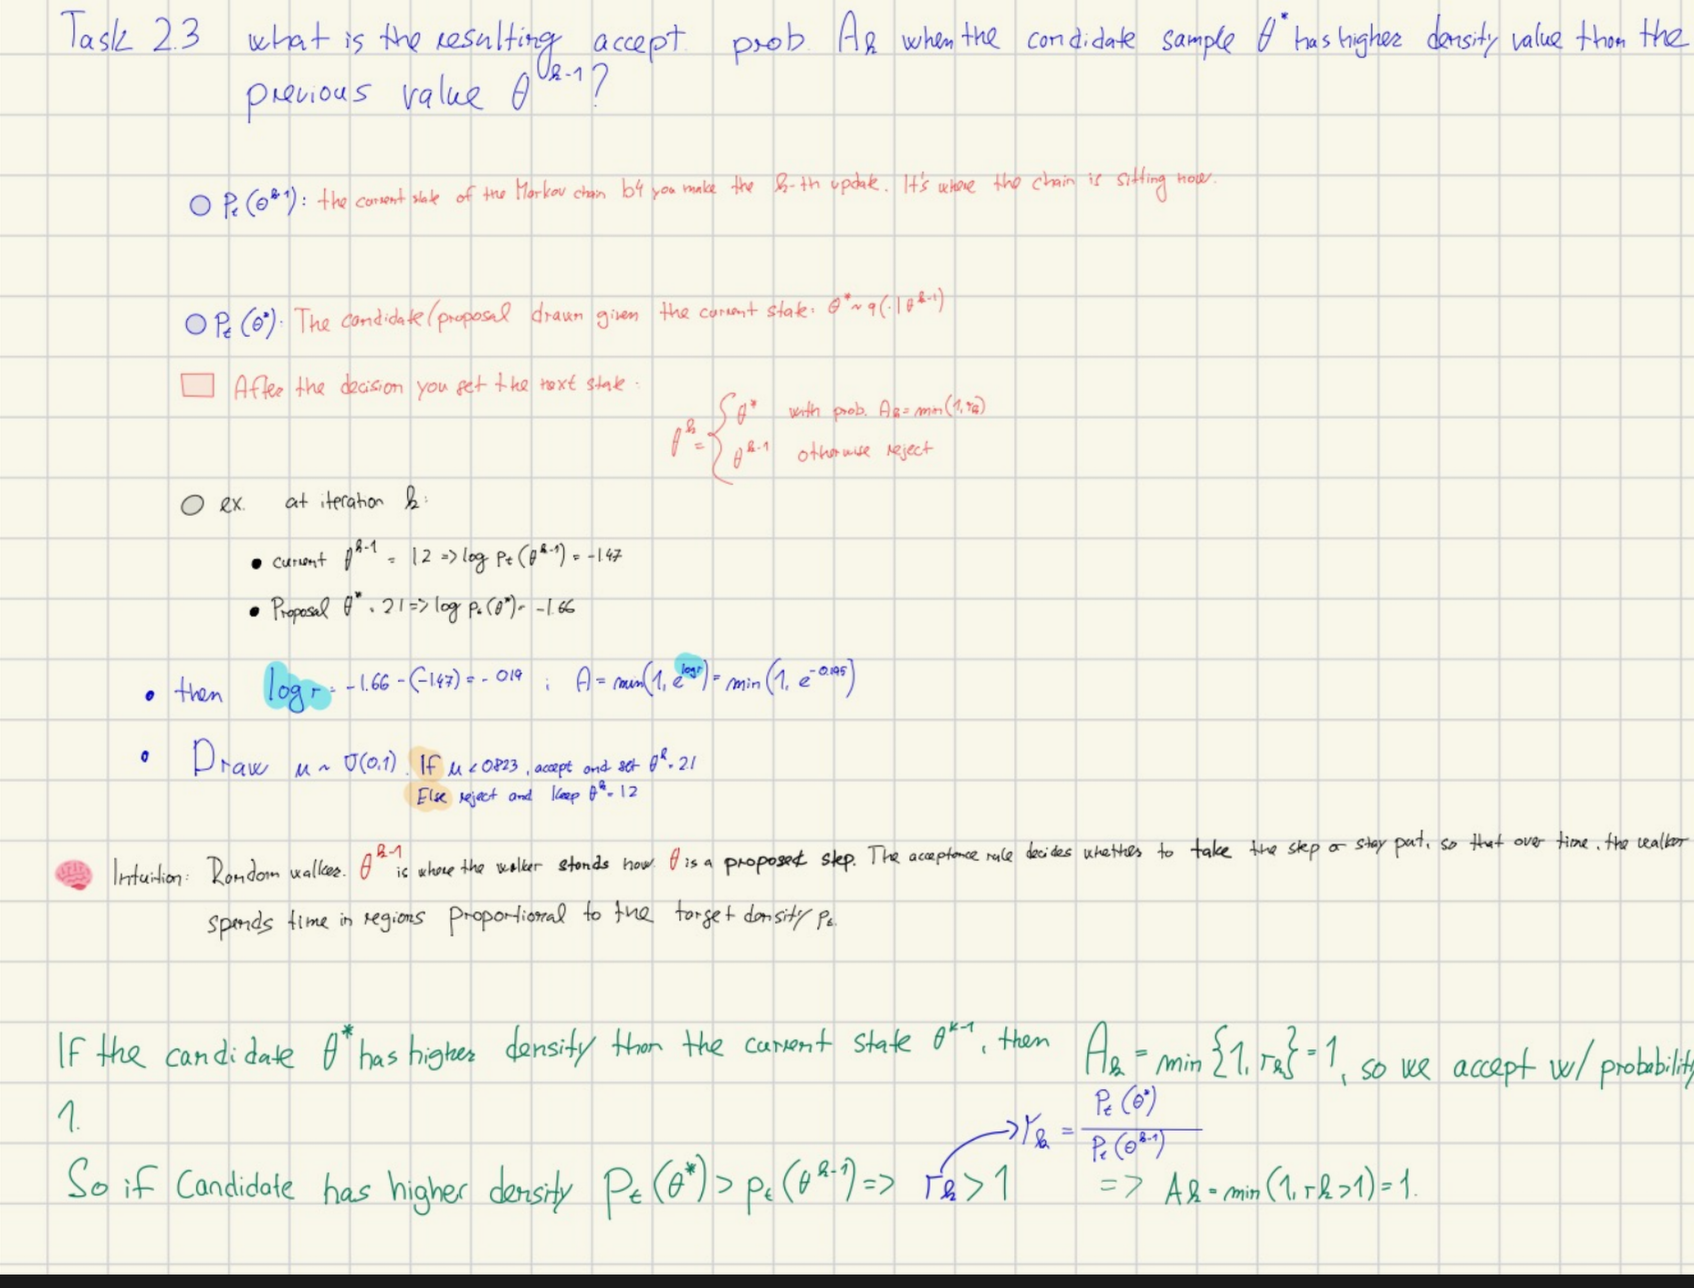




**Task 2.4**: Use eq. (1) one above to argue that we don't need to be able to evaluate the target distribution, but only the target density of up to a constant. That is, we only need to be evaluate $\tilde{p}_t$. Why is this important in Bayesian modelling?



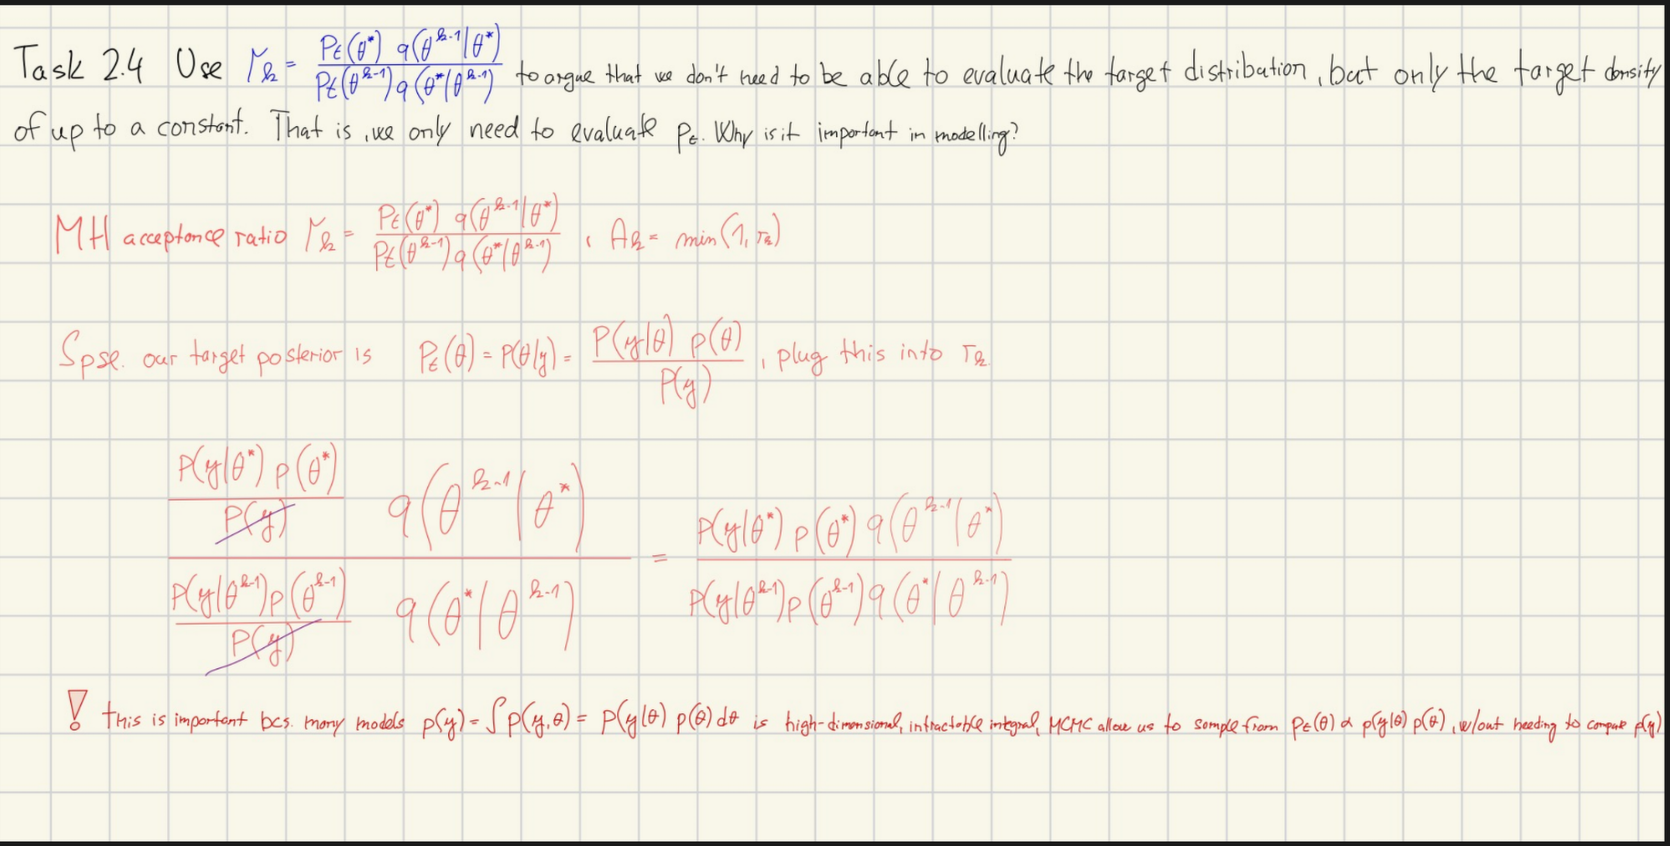

## 🔥 Part 3:  The Metropolis-Hastings algorithm for 1D and 2D problems 

The code below runs the Metropolis-Hastings algorithm for the target distribution specified through the **log_target** function. 

Acceptance ratio: 0.85
Shape of thetas (10001, 1)


Text(0.5, 0.98, 'M-H samplin with $\\tau$ =0.5')

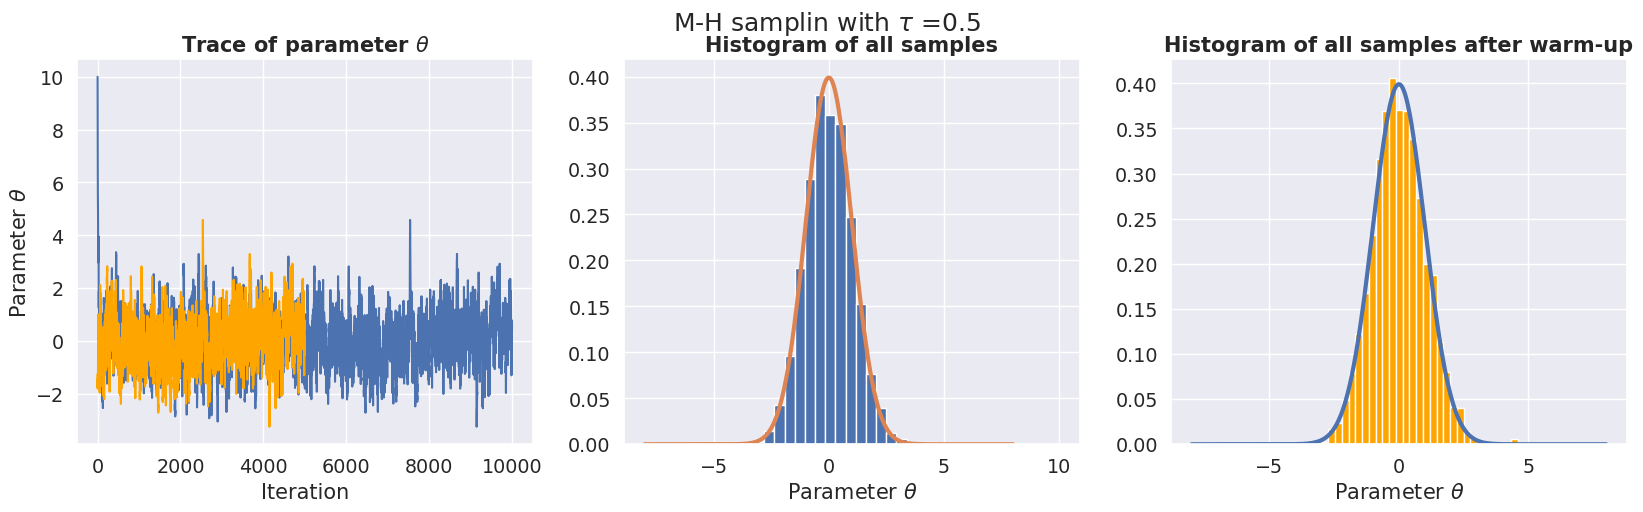

In [41]:
# specify number of parameters in the target distribution
num_params = 1

# specify the target distribution
log_target = lambda x: log_npdf(x, 0, 1)

# specify the parameters of the MH algorithm
num_iterations = 10000
discard = 0.5
warm_up = int(discard*num_iterations)



#key = random.PRNGKey(0)
# Normal(0, 1) initialization
#theta_init = random.normal(key, shape=(num_params,))


#theta_init = jnp.zeros((num_params,))
#theta_init = jnp.array([10])  # shape must match num_params
theta_init = jnp.full((num_params,), fill_value=10)


tau = 0.5

seed = 0

# run sampler
thetas = metropolis(log_target=log_target, num_params=num_params, tau=tau, num_iter=num_iterations, theta_init=theta_init, seed=seed)
print(f"Shape of thetas {thetas.shape}")



# plot resutls
xs = np.linspace(-8, 8, 1000)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(thetas, label='Before warmup')
axes[0].plot(thetas[warm_up:], label=f"After warmup of {warm_up * 100}%", color='orange')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Parameter $\\theta$')
axes[0].set_title('Trace of parameter $\\theta$', fontweight='bold')

axes[1].hist(thetas, 30, density=True);
axes[1].plot(xs, np.exp(log_target(xs)), linewidth=3)
axes[1].set_xlabel('Parameter $\\theta$')
axes[1].set_title('Histogram of all samples', fontweight='bold')

axes[2].hist(thetas[warm_up:], 30, density=True, color='orange');
axes[2].plot(xs, np.exp(log_target(xs)), linewidth=3)
axes[2].set_xlabel('Parameter $\\theta$');
axes[2].set_title('Histogram of all samples after warm-up', fontweight='bold');
fig.suptitle(rf'M-H samplin with $\tau$ ={tau}')


_____

> ✏️ **Task 3.1**: Play around with the initial value of the chain. Why do we need to discard the first proportion of samples (the warm-up phase)? [**Discussion question**]


We set `theta_init = 10.0`, that means we start the Markov chain at $\theta^{(0)} = 10.0$. Which menas, we start away from the high probability region (the mode) of the target distribution, then our chain will need to spend more time exploring the parameter space before it can converge to the high probability region. We take a small steps at the time `theta_star = theta_cur + tau * epsilon`.

**Warm-up phase**

Becasue of it we then discard certain proportion of the samples, which we call the **warm-up phase**. The warm-up phase is the initial part of the Markov chain where it is still exploring the parameter space and has not yet converged to the target distribution. Discarding these samples helps to ensure that our final samples are representative of the target distribution.

___

> ✏️ **Task 3.2**: Go back to the implementation of the `metropolis` function and make the function print the acceptance rate, i.e. the number of accepted samples divided by the total number of iterations.


>  **Task 3.3**: What happens to the acceptance ratio if you change the variance of the proposal distribution, e.g. $\tau = 0.1$, $\tau = 10$ or $\tau=500$? How well does the resulting histogram of the samples match the true target distribution? [**Discussion question**]

- 🔵 $tau=0.1$
- 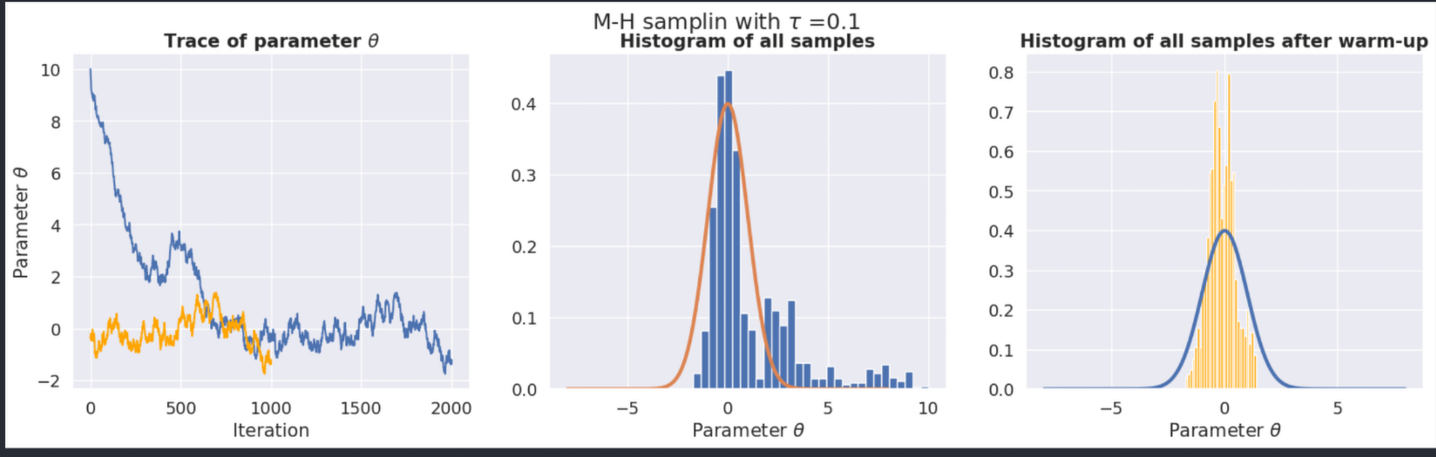

- 🔵 $tau=10$
- 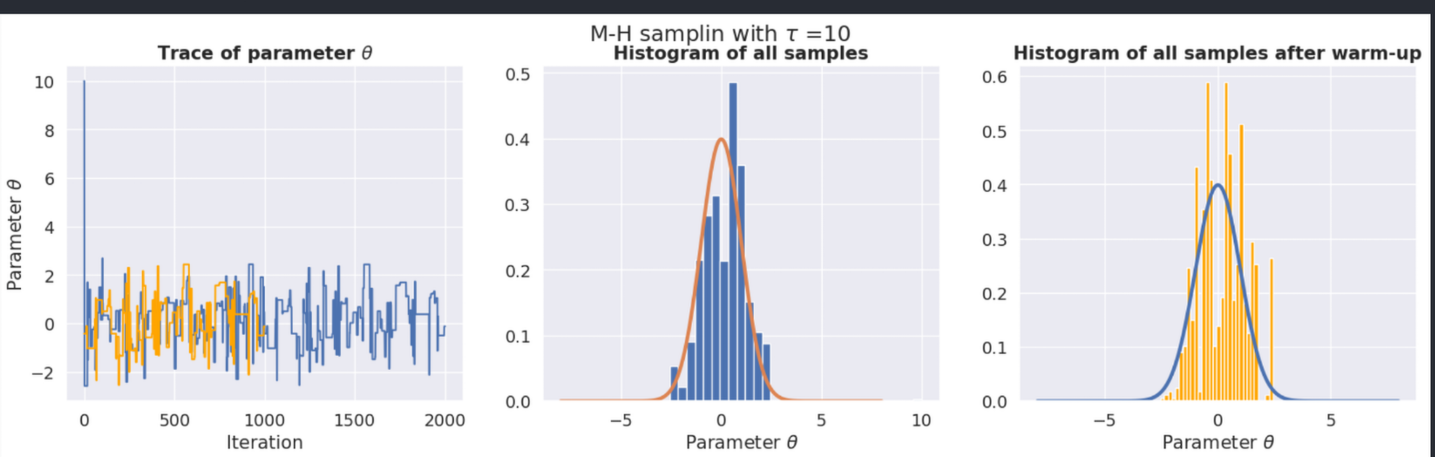

- 🔵 $tau=500$
- 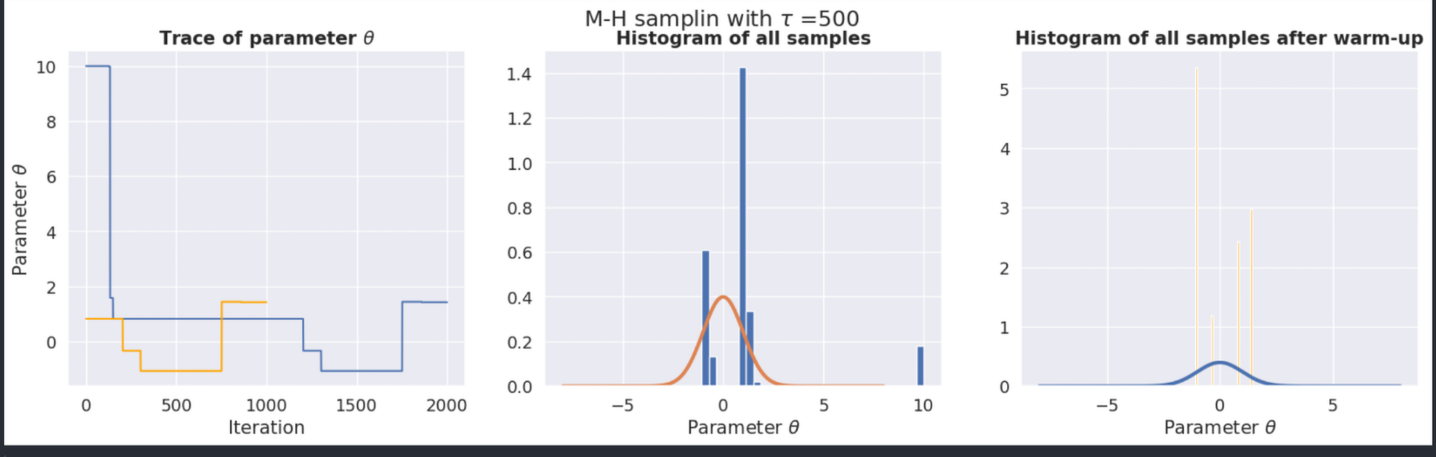

**🧭 What the Acceptance Ratio Tells You**

The **acceptance ratio** is defined as:

$$
\text{acceptance ratio} = \frac{\text{Number of accepted proposals}}{\text{Total proposals}} \in [0, 1]
$$

It tells you how often the Markov chain accepts a proposed move. This has two key implications:

- **High acceptance rate** ($ \approx 1 $): Many proposals are accepted, but you might be making very **small steps**. This can lead to **poor exploration** of the parameter space (low mixing).

- **Low acceptance rate** ($ \approx 0 $): Most proposals are **rejected**, so the chain **gets stuck**. This also leads to poor mixing and slow convergence.

**✅ Goal: A Balance**

A good acceptance rate is typically somewhere between **20% and 50%**, depending on the problem and dimensionality. This balance ensures that the chain both **explores** and **moves efficiently** through the space.

**📉 What Happens as You Vary $\tau$**

**1. $\tau = 0.1$ (tiny steps)**

Proposal distribution:

$$
\theta^* = \theta + 0.1 \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

**Result**: Small changes from one sample to the next.

**Outcome**:
- ✅ High acceptance rate (e.g., ~90–99%)
- ❌ Slow exploration (high autocorrelation, poor mixing)
- ❌ Histogram may look overly sharp and not capture full tails


**2. $\tau = 10$ (big steps)**

Proposal jumps are large.

Many $\theta^*$ fall in **low-probability** regions of the target.

**Result**:
- ❌ Low acceptance rate (e.g., ~1–5%)
- ❌ Chain rejects most moves → poor exploration and slow mixing
- ❌ Histogram is under-sampled and may be noisy


**3. $\tau = 500$ (huge steps)**

Almost all proposals are in **very low-density** regions.

**Acceptance rate** approaches **zero**.

**The chain barely moves** — it stays where it started.

**Result**: 🚫 Essentially no sampling — total failure

**🔬 Summary: What the acceptance ratio tells you**

| τ (proposal std) | Acceptance Ratio | Behavior           | Problem                       |
| ---------------- | ---------------- | ------------------ | ----------------------------- |
| Very small (≪1)  | ≫ 0.5            | Accepts everything | Poor exploration (tiny steps) |
| Moderate (\~1–2) | 0.2 – 0.4        | Good balance       | ✔️ Ideal                      |
| Very large (≫1)  | ≪ 0.1            | Rejects most       | Gets stuck                    |

______

> **Task 3.4**: Using $\tau = 0.5$ and keeping warm up at 50%, how many iterations do you need before distribution of the samples resembles the target distribution (based on a visual comparison of the target density and the histogram of the samples)? [**Discussion question**]

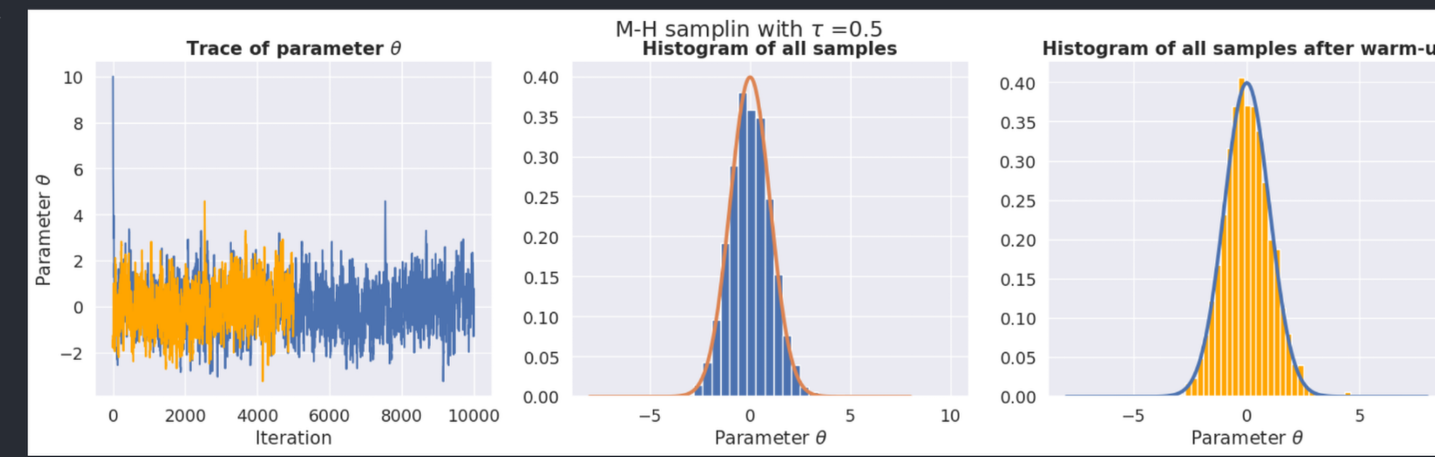

I got best result using N=10000 iterations, where the histogram of the samples resembles the target distribution. 

> **Task 3.5**: Use the MH-algorithm to estimate the mean, the variance and the probability that $\theta > 1$ for the following two distributions given below. 

*Hints*
- *Plot the trace to verify that the chains appear to have converged. If not adapt the proposal variance and/or the number of samples*
- *Plot the target densities as well as the histogram of the resulting samples to verify that everything looks ok*


$$\begin{align*}
p(\theta) &\propto \exp(-|\theta-3|)\\
p(\theta) &= \frac{3}{40}\exp(-\frac12 |\theta-3|) + \frac{7}{20} \exp(-|\theta+2|)  \\
p(\theta) &= 2\phi(\theta)\Phi(5\theta),
\end{align*}$$


where $\phi(\cdot)$ and $\Phi(\cdot)$ is the PDF and CDF a standarized normal distribution, respectively. The first distributions in an instance of the family of [Laplace distributions](https://en.wikipedia.org/wiki/Laplace_distribution), the second is a mixture of Laplace distributions and the last distribution is an instance of the family of [skew-normal distributions](https://en.wikipedia.org/wiki/Skew_normal_distribution).





Acceptance ratio: 0.40
20001
(20001, 1)


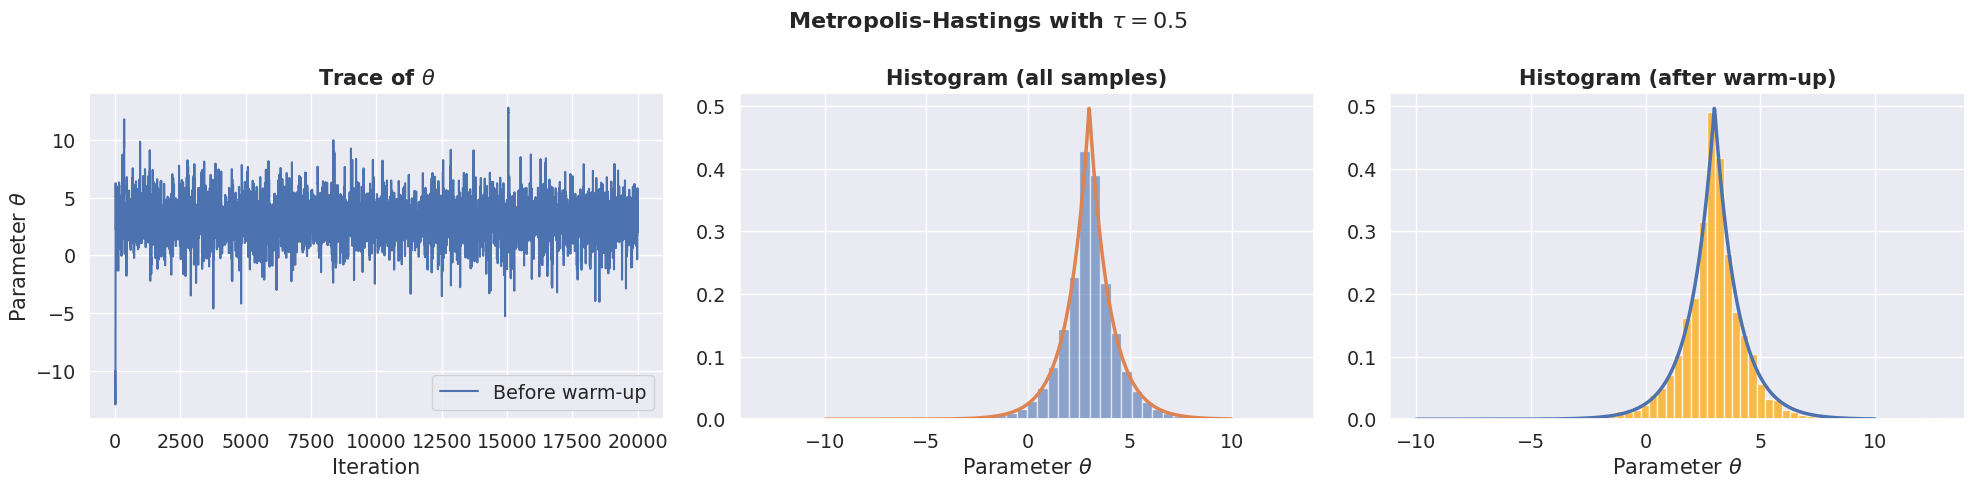

In [82]:
p_theta1 = lambda x: -jnp.log(2) - jnp.abs(x - 3) 

thetas_p_theta_1 = metropolis(p_theta1, num_params=1, tau=3, num_iter=20000, theta_init=jnp.array([-10]), seed=0)

xs = np.linspace(-10, 10, 1000)
discard = 0.5
warm_up = int(discard*20000)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Trace plot
axes[0].plot(thetas_p_theta_1, label='Before warm-up')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel(r'Parameter $\theta$')
axes[0].set_title(r'Trace of $\theta$', fontweight='bold')
axes[0].legend()

# Histogram of all samples
axes[1].hist(thetas_p_theta_1, bins=50, density=True, alpha=0.6)
axes[1].plot(xs, jnp.exp(p_theta1(xs)), linewidth=2.5)
axes[1].set_xlabel(r'Parameter $\theta$')
axes[1].set_title('Histogram (all samples)', fontweight='bold')

# Histogram of post-warm-up samples
axes[2].hist(thetas_p_theta_1[warm_up:], bins=50, density=True, color='orange', alpha=0.7)
axes[2].plot(xs, jnp.exp(p_theta1(xs)), linewidth=2.5)
axes[2].set_xlabel(r'Parameter $\theta$')
axes[2].set_title('Histogram (after warm-up)', fontweight='bold')

fig.suptitle(rf'Metropolis-Hastings with $\tau = {tau}$', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

#### The Metropolis-Hastings algorithm for 2D problems

Next, we will apply MH algorithm to generate samples from a bivariate normal distribution with correlation $\rho$. That is, the target density is

\begin{align*}
p(\mathbf{\theta}) = \mathcal{N}(\mathbf{\theta}|\mu, \Sigma),
\end{align*}

where $\mathbf{\theta} \in \mathbb{R}^2$, $\mathbf{\mu} = \begin{bmatrix}-4\\ 4\end{bmatrix}$, and $\mathbf{\Sigma} = \begin{bmatrix}1 & \rho \\ \rho & 1\end{bmatrix}$.

There are, of course, much more efficient ways to generate samples from multivarate normal distributions, but here we use the multivariate normal distribution to understand the properties of the MH algorithm.

Acceptance ratio: 0.46
5001
(5001, 2)
Mean and variance of samples for theta1: -4.03, 1.04
Relative Error of the mean 0.007419500034302473
Relative Error of the mean 0.03455408662557602
Mean and variance of samples for theta2: 3.96, 1.02
Relative Error of the mean 0.011174846440553665
Relative Error of the mean 0.03455408662557602


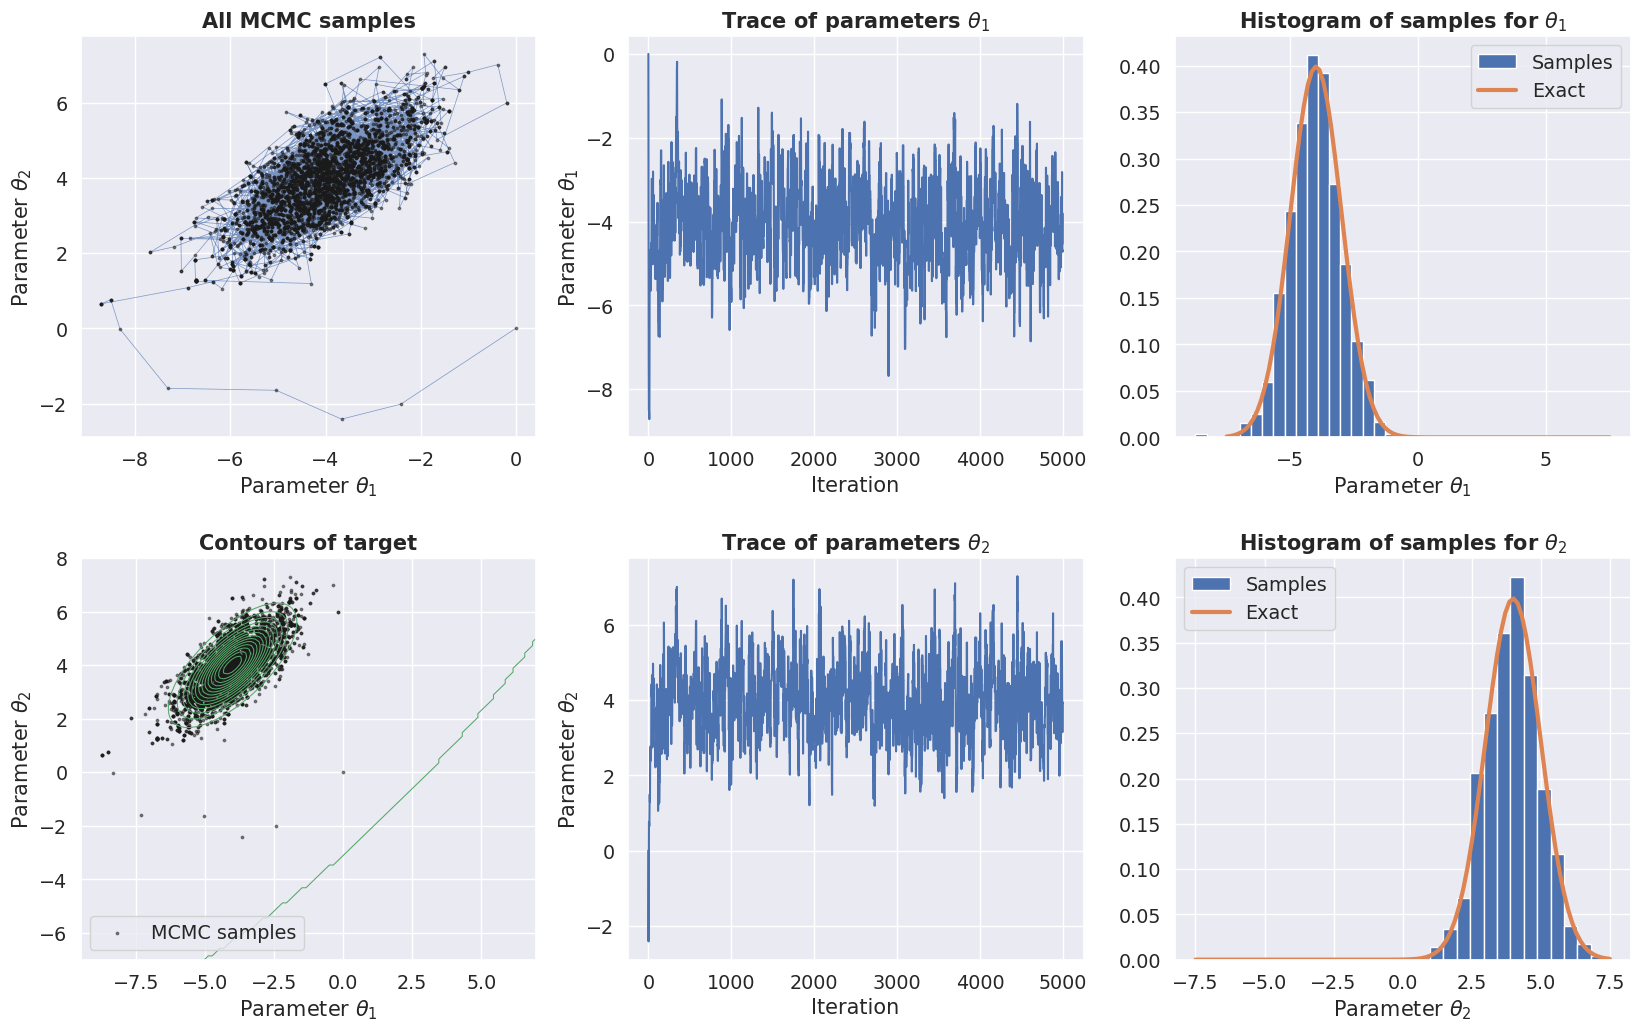

In [88]:
# specify target density
mu = jnp.array([-4, 4])                            # mean 
rho = 0.7                                         # correlation coef.
S = jnp.array([[1, rho], [rho, 1]])                # covariance matrix
log_joint = lambda x: mvn.logpdf(x, mu, S)        # target density

true_mean = mu
true_var = jnp.diag(S)


# sampler settings
num_params = 2
num_iterations = 5000
warm_up = int(0.5*num_iterations)
tau = 0.99

# run sampler
thetas = metropolis(log_joint, num_params, tau, num_iterations, seed=0)

# discard samples from warm-up phase
#thetas = thetas[warm_up:, :]

# plot
xs = jnp.linspace(-7.5, 7.5, 100)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes[0, 0].plot(*thetas.T, lw=0.5, alpha=0.7, zorder=1)
axes[0, 0].scatter(*thetas.T, c="k", s=3, alpha=0.5, zorder=2)
axes[0, 0].set_xlabel('Parameter $\\theta_1$')
axes[0, 0].set_ylabel('Parameter $\\theta_2$')
axes[0, 0].set_title('All MCMC samples', fontweight='bold')


x_grid, log_density_grid = eval_density_grid(log_joint)
axes[1, 0].scatter(*thetas.T, c="k", s=3, alpha=0.5, label='MCMC samples')
axes[1, 0].contour(x_grid, x_grid, jnp.exp(log_density_grid), levels=15, linewidths=0.75, colors='g')
axes[1, 0].set_xlabel('Parameter $\\theta_1$')
axes[1, 0].set_ylabel('Parameter $\\theta_2$')
axes[1, 0].set_title('Contours of target', fontweight='bold')
axes[1, 0].legend()

for i in range(2):
    axes[i, 1].plot(thetas[:, i])
    axes[i, 1].set_title('Trace of parameters $\\theta_{%d}$' % (i+1), fontweight='bold')
    axes[i, 1].set_xlabel('Iteration')
    axes[i, 1].set_ylabel('Parameter $\\theta_{%d}$' % (i+1))
    
    axes[i, 2].hist(thetas[:, i], 20, density=True, label='Samples')
    axes[i, 2].set_xlabel('Parameter $\\theta_{%d}$' % (i+1))
    axes[i, 2].plot(xs, npdf(xs, mu[i], S[i,i]), linewidth=3, label='Exact')
    axes[i, 2].set_title('Histogram of samples for $\\theta_{%d}$' % (i+1), fontweight='bold')
    axes[i, 2].legend()
    
    print('Mean and variance of samples for theta%d: %3.2f, %3.2f' % (i+1, jnp.mean(thetas[:, i]), jnp.var(thetas[:, i])) )
    real_err_mean = jnp.abs(jnp.mean(thetas[:, i] - true_mean[i]) / jnp.abs(true_mean[i]))
    real_err_var = jnp.abs(jnp.var(thetas[:, i] - true_var[i] ) / true_var[i])
    print(f"Relative Error of the mean {real_err_mean}")
    print(f"Relative Error of the mean {rel_err_var}")
    
fig.subplots_adjust(hspace=0.3)


**Task 3.6**: Experiment with the number of iterations. How many iterations do you need before the sample mean and variance are equal to the true values (up to, say, 5%-10% relative error)? [**Discussion question**]


Around 5000 iterations are needed to get the relative error below 5% for the mean and variance.

**Task 3.7**: What happens to the acceptance ratio if you increase the correlation in the target density to, say, $\rho = 0.7$, $\rho=0.9$, $\rho=0.95$ or $\rho=0.99$? What happens to the accuracy of the moments? [**Discussion question**]


 ## 🚀 Part 4:  Metroplis-Hastings for Bayesian Poisson regression

Now we will apply the Metropolis-Hastings algorithm to Bayesian Poisson regression (discussed in week 7). As a case study, we will use a small data set from a study on mortality (Broffiti, 1988), where the authors looked at the mortality rates as a function of age. 

Let's look at the data.

/home/pnylander/miniconda3/envs/02477_Bayesian_Machine_Learning/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


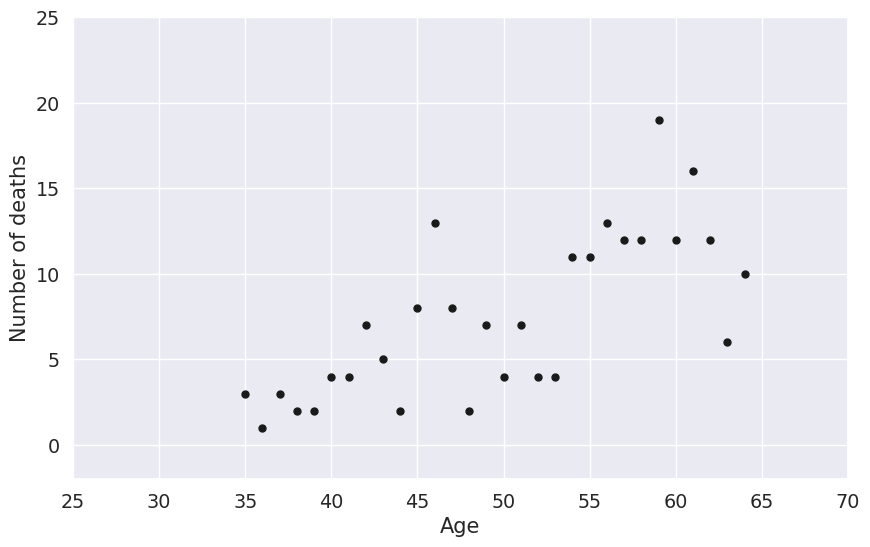

In [64]:
###################################################
# Raw data
###################################################

# The input covariate is age
age = jnp.arange(35, 65).astype(jnp.float64)

# The output is the number of deaths in the study popular for each age
deaths = jnp.array([3, 1, 3, 2, 2, 4, 4, 7, 5, 2, 8, 13, 8, 2, 7, 4, 7, 4, 4, 11, 11, 13, 12, 12, 19, 12, 16, 12, 6, 10])

# number of data points
N = len(deaths)

# Let's standardize the input covariate
m_age = jnp.mean(age)
s_age = jnp.std(age)
standardize = lambda x: (x-m_age)/s_age

# prep data
x = standardize(age)
x = x[:, None]

# Define input points for prediction
age_star = jnp.linspace(25, 70, 100)
x_star = standardize(age_star)

# Let's set-up the design matrix for the training data and the inputs for predictions
design_matrix = lambda x: jnp.column_stack((jnp.ones(len(x)), x))
X_train = design_matrix(x)
X_star = design_matrix(x_star)

# Plotting
def plot_data(ax=None):
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
    ax.plot(age, deaths, 'k.', markersize=10)
    ax.set_xlabel('Age')
    ax.set_ylabel('Number of deaths')
    
    ax.set_xlim((25, 70))
    ax.set_ylim((-2, 25))


plot_data()

**Linear models for count data**

We will a use **generalized linear model** to model this dataset. Since the target variable $y_n$ is **count data**, i.e., $y_n \in \left\lbrace 0, 1, 2, \dots \right\rbrace$, we will use a Poisson likelihood to model the data. If you don't recall what the Poisson distribution looks like, then the Wikipedia page is useful: https://en.wikipedia.org/wiki/Poisson_distribution. 

The likelihood of a **single data point** is given by

\begin{align*}
y_n|\mu_n \sim \text{Poisson}(\mu_n),
\end{align*}

where $\mu_n > 0$ is the mean parameter for the Poisson distribution for the $n$'th observation, i.e., $\mathbb{E}_{y_n|\mu_n}\left[y_n\right] = \mu_n$.

Since count data are non-negative, we will use the **log link function** 

\begin{align*}
\log(\mu_n) = f_n \quad\quad \iff \quad \quad \mu_n = \exp(f_n),
\end{align*}

where $f_n = f(\mathbf{x}_n)$ is a linear model with parameters $\mathbf{w} \in \mathbb{R}^2$ evaluated at $\mathbf{x}_n$:

\begin{align*}
f(\mathbf{x}) = \mathbf{w}^T \mathbf{x}_n = w_0 + w_1\cdot\text{age},
\end{align*}

with $\mathbf{x}_n = \begin{bmatrix}1\\\text{age}_n\end{bmatrix}$, where the first element is the intercept and the second element is the age of the $n$'th observation.


> 🧠**Intuition (multiplicative effects)**: Because of the log link, the linear predictor $f_n$ acts additively on the log‑mean but multiplicatively on the mean count. A one‑unit increase in age multiplies the expected count by $\exp(w_1)$. For example, if $w_1=0.05$, each additional year increases the mean count by about 5.1%; a 10‑year increase multiplies the mean by $\exp(0.5) \approx 1.65$.


The model has two parameters: an intercept $w_0$ and a slope $w_1$. To perform Bayesian inference, we will impose a zero-mean Gaussian prior distribution on both:

\begin{align*}
p(\mathbf{w}|\kappa^2) = \mathcal{N}(\mathbf{w}|\mathbf{0}, \kappa^2 \mathbf{I}),
\end{align*}

where $\kappa^2 > 0$ is the variance of the prior. 


> **💡 Practical tip**: Practical tip (centering/scaling): It is often helpful to center age (e.g., subtract the sample mean) or even standardize it. Then $w_0$ becomes the log‑expected count at the average age, which is easier to interpret and numerically stabilizes inference.


**Hyperpriors**

Earlier in the course, we estimated **hyperparameters** like $\kappa$ by optimizing the marginal likelihood. However, since we are dealing with a rather small dataset, we will use **fully Bayesian** and impose a **hyperprior** distribution on $\kappa$. That is, we consider $\kappa$ a random variable and impose a prior distribution on it. Specifically, we will use a **half-normal distribution** as prior for $\kappa$:
\begin{align*}
\kappa \sim \mathcal{N}_+(0, 1)
\end{align*}

The half-normal distribution is just the "positive-part" of a standard normal distribution (https://en.wikipedia.org/wiki/Half-normal_distribution) and it serves to prevent to prior variance of $\mathbf{w}$ from becoming too large such that we risk overfitting.

> 🧠**Intuition** (shrinkage): $\kappa$ controls how far the coefficients are allowed to wander from zero. Small $\kappa$ values pull $\mathbf{w}$ toward $\mathbf{0}$ (strong regularization), while larger $\kappa$ permit more flexibility. Learning $\kappa$ from the data balances bias and variance automatically.

**The full probabilistic model**

To summarize, the full probabilistic model looks as follows:

\begin{align*}
y_n|\mu_n &\sim \text{Poisson}(\mu_n),\\
\mu_n &= \exp(f_n)\\
f_n &= \mathbf{w}^T \mathbf{x}_n\\
\mathbf{w}|\kappa &= \mathcal{N}(0, \kappa^2\mathbf{I})\\
\kappa &\sim \mathcal{N}_+(0, 1)
\end{align*}


The joint distribution of the model is given by
\begin{align*}
p(\mathbf{y}, \mathbf{w}, \kappa) = \bigg[\prod_{n=1}^N p(y_n|\mathbf{w})\bigg]p(\mathbf{w}|\kappa)p(\kappa),
\end{align*}

where we have used $y_n|\mathbf{w} \sim \text{Poisson}(\exp(y;\mathbf{w}^T \mathbf{x}_n))$. 

Equivalently, the full-data likelihood and log-likelihood are

$$
L(\mathbf{w}) = \prod_{n=1}^{N} \frac{\exp\left(y_n f_n - \exp(f_n)\right)}{y_n!},
$$

$$
\log L(\mathbf{w}) = \sum_{n=1}^{N} \left(y_n f_n - \exp(f_n)\right) - \sum_{n=1}^{N} \log(y_n!).
$$

The term $\sum \log(y_n!)$ does not depend on $\mathbf{w}$ and can be treated as a constant when optimizing or sampling $\mathbf{w}$.



>  **🧠Intuition (canonical link):** The log link is the canonical link for Poisson GLMs. It makes the natural parameter equal to $f_n$, which yields convenient gradients and well-behaved optimization/sampling.



One way to understand this model is to consider the "generative story" (via ancestral sampling):
1. Nature samples a value for $\kappa \sim \mathcal{N}_+(0, 1)$.
2. Using that specific value of $\kappa$, nature picks a set of weights $\mathbf{w}|\kappa^2 = \mathcal{N}(0, \kappa^2\mathbf{I})$.
3. Using those specific weights, nature computes the mean value $\mu_n$ for all observations at $\mathbf{x}_n$, i.e. $\mu_n = \exp(\mathbf{w}^T \mathbf{x}_n)$.
4. Finally, nature picks a value for each observation $y_n$ by sampling from $y_n|\mu_n \sim \text{Poisson}(\mu_n)$.


**Posterior inference and making predictions**

Our strategy will be as follows. We will implement a function for evaluating the log joint distribution, and then we will use MCMC (via the Metropolis-Hastings algorithm) to generate samples from the posterior $p(\mathbf{w}, \kappa|\mathbf{y})$. Next, we will use ancestral sampling to generate samples of

-  $f^* = f(\mathbf{x}^*) = \mathbf{w}^T \mathbf{x}^*$,
-  $\mu^* = \exp(f^*)$,
-  $y^*|\mu^* \sim \text{Poisson}(\mu^*)$

for each $\mathbf{x}^*$. Finally, we can compute the desired summary statistics of $y^*$ based on the generated samples.


To be able to use our implementation of the Metropolis-Hastings algorithm, we will define $\theta \in \mathbb{R}^3$ to be a three-dimensional vector containing all 3 parameters to be estimated, i.e. $\theta  = \left[w_0, w_1, \kappa \right]$. 


**Task 4.1**: Implement a function for evaluating the log joint distribution of the Poisson regression model as a function of $\theta$. 

*Hint:*
- *You can use `scipy.stats.poisson.logpmf` to implement the likelihood*
- *Recall $\kappa > 0$ is a stricly positive parameter and hence $p(\kappa) = 0$ for $\kappa < 0$*



In [ ]:
def log_likelihood()

**Task 4.2**: Use the Metropolis-Hastings algorithm to generate samples from the posterior $p(\theta|\mathbf{y})$. Make trace plots of all parameters and ensure that the chain appear to have converged.




**Task 4.3**: Plot a histogram of the posterior samples of $\kappa$ and compare with a histogram of prior samples of $\kappa$. Generate a scatter plot of the posterior samples of the weights and compare to a scatter plot of prior samples of the weights. Based on these plots: do you think the data is more informative about the weights of the linear model $\mathbf{w}$ or the hyperparameter $\kappa$?



### Making predictions

Now that we have posterior samples for the weights, i.e. $\mathbf{w}^{(i)} \sim p(\mathbf{w} | \mathbf{y})$, we can use them to compute and plot the posterior predictive distribution $p(y^*|\mathbf{y}, \mathbf{x}^*)$ for age between 25 and 70 for our Bayesian Poisson regression model using MC sampling:

$$\begin{align*}
f_*^{(i)} &= (\mathbf{w}^{(i)})^T\mathbf{x}^*\\
\mu_*^{(i)} &= \exp(f_*^{(i)})\\
y_*^{(i)} &\sim \text{Poisson}(\mu_*^{(i)})
\end{align*}$$


for each posterior sample $i = 1, 2, \dots, S$. 

The variable `X_star` is a (P x 2)-shaped array, which contains the input values for the predictions, where $P = 100$ is the number of points in the interval from 25 to 70.

**Task 4.4**: Complete the implementation of the variable `f_star_samples`, `mu_star_samples`, and `y_star_samples`, which should all be (P x num_mcmc_samples)-shapes arrays containing posterior/posterior predictive samples of $f^*$, $\mu^*$ and $y^*$, respectively.

In [ ]:
# making predictions by mapping the posterior samples of theta = (w, kappa) through the model
 f_star_samples = <insert your solution here> # the result must be a (100 x num_mcmc_samples)-array 
 mu_star_samples = <insert your solution here> # the result must be a (100 x num_mcmc_samples)-array 
 y_star_samples = <insert your solution here> # the result must be a (100 x num_mcmc_samples)-array 

# plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_predictions(axes[0], age_star, f_star_samples.T, num_samples=0, legend=True, title='Posterior of $f_*|\\mathbf{y}$')
plot_predictions(axes[1], age_star, mu_star_samples.T, num_samples=0, legend=True, title='Posterior of $\\mu_*|\\mathbf{y}$')
plot_predictions(axes[2], age_star, y_star_samples.T, num_samples=0, legend=True, title='Predictive distribution $y_*|\\mathbf{y}$')
plot_data(axes[1])
plot_data(axes[2])

**Task 4.5**: Compute and visualize the posterior distributions for $f_*, \mu_*, y_*$ for $\text{age} = 75$ and report the mean and standard deviation of $p(y_*|\mathbf{y})$ for $\text{age} = 75$





## 🇨🇿 Part 5:  Importance sampling



In the final part, we will briefly look at **importance sampling**. Recall, importance sampling is tool for estimating expectations of a function $f$ wrt. a target distribution $p$ using samples from a **proposal distribution** $q$:

$$\begin{align*}
\mathbb{E}_p \left[f(z)\right] = \mathbb{E}_q \left[f(z) \frac{p(z)}{q(z)}\right] \approx \frac{1}{S}\sum_{i=1}^S w^{(i)} f(z^{(i)}) \equiv \hat{f}, \quad z^{(i)} \sim q(z) \quad \text{for} \quad i = 1, \dots, S,
\end{align*}$$

where the **importance weights** $w^{(i)}$ are given by $w^{(i)} = \frac{p(z^{(i)})}{q(z^{(i)})}$. 

Consider again the following Skew-normal distribution:


$$\begin{align*}
p(z) &= 2\phi(z)\Phi(5z),
\end{align*}$$

which is plotted below:

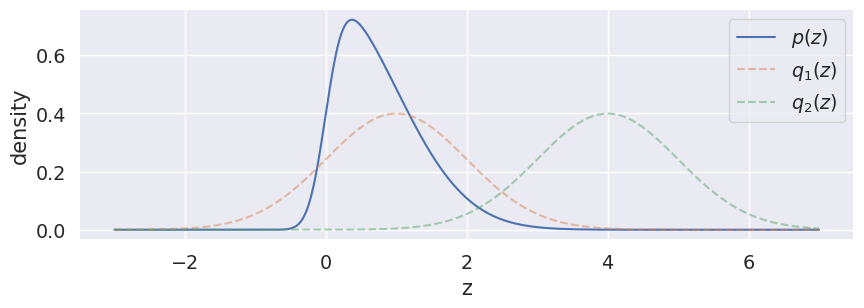

In [68]:
p = lambda z: 2*norm.pdf(z)*norm.cdf(5*z)
q1 = lambda z: npdf(z, 1,1)
q2 = lambda z: npdf(z, 4,1)

zs = np.linspace(-3, 7, 1000)
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(zs, p(zs), label='$p(z)$')
ax.plot(zs, q1(zs), label='$q_1(z)$', linestyle='--', alpha=0.5)
ax.plot(zs, q2(zs), label='$q_2(z)$', linestyle='--', alpha=0.5)
ax.set(xlabel='z', ylabel='density')
ax.legend();

The analytical mean of the distribution is given by 

$$\begin{align*}
\mathbb{E}\left[z\right] = \frac{5}{\sqrt{1+5^2}}\sqrt{\frac{2}\pi} \approx 0.7824
\end{align*}$$

**Task 5.1**: Use importance sampling with a Gaussian proposal, $q(z) = \mathcal{N}(z|1, 1)$, to estimate the mean of the target distribution $p$ for $S = 1000$. How many samples $S$ do you need to get a decent estimate?

*Hints*:
- *Implement a function for computing the importance sampling estimate wrt. the target distribution given the mean and variance of the proposal distribution as well as number of samples to use.*



The importance sampling estimator is an **unbiased** estimator, but for importance sampling to work well in practice, the proposal distribution $q$ needs to be relatively "well-aligned" with the target distribution $p$. In the next task, you are going to design a small numerical experiment to investigate this.

**Task 5.2**: Consider two different proposal distributions $q_1(z) = \mathcal{N}(z|1,1)$ and $q_2(z) = \mathcal{N}(z|4,1)$. Compute and plot the importance sampling estimate for the mean of $p(z)$ for both proposal distributions as a function the sample size $S$. Since the importance sampling is an inherently stochastic procedure, you should consider repeating the experiment several times and plot the mean and variance of the estimator across the repetitions as a function of $S$.

*Hints*:
- *There are many valid ways to implement this. The simplest is likely to be via nested for-loops, e.g. an "inner" for loop over the sample size and an "outer" for-loop over the repetitions*
- *Consider $S$ in the range from $S = 1$ to $S = 10^4$.*
- *Remember to use a different seed/key for each repetition.*

